# Section 02: Chunking Strategies for Financial Documents

**Duration:** ~60 minutes  
**Goal:** Understand that *how* you split a document is as important as the retrieval itself, and compare 4 strategies on the same annual report.

---

## Why Chunking Matters

Chunking is like **deciding how to index a book**.

Imagine you are indexing the NMB Bank Annual Report:
- **By sentences** → Very granular. *"Net profit was NPR 2.3 billion"* is one chunk. Good for precise lookups, but loses surrounding context.
- **By chapters** → Very broad. Each chunk is 20 pages. The answer is buried inside — retrieval is noisy.
- **By fixed size** → Predictable. Sometimes cuts mid-sentence or mid-table.
- **By meaning** → Best of both worlds. Chunks end where the topic naturally ends.

For financial documents — which have **tables, footnotes, ratio calculations, and narrative sections** — chunking strategy significantly changes answer quality.

## The 4 Strategies We Will Compare

```
Same PDF Document
       │
       ├──► Fixed-Size Chunking      ──► ChromaDB-1 ──┐
       │                                               │
       ├──► Sentence-Based Chunking  ──► ChromaDB-2 ──┤
       │                                               ├──► Same Query ──► Compare Answers
       ├──► Paragraph-Based Chunking ──► ChromaDB-3 ──┤
       │                                               │
       └──► Semantic Chunking        ──► ChromaDB-4 ──┘
```

| Strategy | Split Logic | Pros | Cons |
|----------|-------------|------|------|
| **Fixed-size** | Every N tokens | Predictable, fast | Cuts mid-sentence/mid-table |
| **Sentence-based** | `.`, `?`, `!` | Preserves sentence integrity | Loses multi-sentence context |
| **Paragraph-based** | `\n\n` | Preserves logical sections | Paragraphs vary wildly in length |
| **Semantic** | Cosine distance between sentences | Topic-aware splits | Slower, needs embeddings upfront |

In [1]:
# ── Setup check: verify the sample PDFs are in place ─────────────────────────
import os, subprocess, sys
from pathlib import Path

DATA_DIR = Path("../data").resolve()
PDF_PATHS = [
    DATA_DIR / "annual_reports" / "nmb_bank_annual_report_2023.pdf",
    DATA_DIR / "annual_reports" / "nmb_bank_annual_report_2022.pdf",
    DATA_DIR / "annual_reports" / "nepal_telecom_annual_report_2023.pdf",
]

if any(not p.exists() for p in PDF_PATHS):
    print("Some PDFs missing — running data generator...")
    subprocess.run([sys.executable, str(DATA_DIR / "generate_sample_data.py")],
                   check=True, cwd=str(DATA_DIR))

print("All required PDFs are present.")
if not os.environ.get("OPENAI_API_KEY"):
    print("WARNING: OPENAI_API_KEY is not set.")


All required PDFs are present.


In [2]:
import os
import re
import textwrap
import numpy as np

import chromadb
import nltk
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from openai import OpenAI
from pypdf import PdfReader

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
EMBED_MODEL = "text-embedding-3-small"
enc = tiktoken.get_encoding("cl100k_base")

# Load the PDF
PDF_PATH = "../data/annual_reports/nmb_bank_annual_report_2023.pdf"
reader = PdfReader(PDF_PATH)
full_text = "\n".join(page.extract_text() or "" for page in reader.pages)
print(f"Loaded {len(reader.pages)} pages, {len(full_text):,} characters.")

Loaded 5 pages, 7,406 characters.


In [3]:
# ── Strategy 1: Fixed-size chunking ──────────────────────────────────────────
def fixed_size_chunks(text: str, chunk_size: int = 500, overlap: int = 50) -> list[str]:
    tokens = enc.encode(text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + chunk_size, len(tokens))
        chunks.append(enc.decode(tokens[start:end]))
        start += chunk_size - overlap
    return chunks

chunks_fixed = fixed_size_chunks(full_text)

print(f"Fixed-size chunks : {len(chunks_fixed)}")
print(f"Avg length        : {int(np.mean([len(c) for c in chunks_fixed]))} chars")
print()
for i, c in enumerate(chunks_fixed[5:8], start=6):
    print(f"  Chunk {i}: {c[:180].strip()}...\n")

Fixed-size chunks : 5
Avg length        : 1647 chars



In [4]:
# ── Strategy 2: Sentence-based chunking ──────────────────────────────────────
from nltk.tokenize import sent_tokenize

def sentence_chunks(text: str, sentences_per_chunk: int = 5, overlap: int = 1) -> list[str]:
    sentences = sent_tokenize(text)
    chunks = []
    start = 0
    while start < len(sentences):
        end = min(start + sentences_per_chunk, len(sentences))
        chunks.append(" ".join(sentences[start:end]))
        start += sentences_per_chunk - overlap
    return chunks

chunks_sentence = sentence_chunks(full_text)

print(f"Sentence-based chunks : {len(chunks_sentence)}")
print(f"Avg length            : {int(np.mean([len(c) for c in chunks_sentence]))} chars")
print()
for i, c in enumerate(chunks_sentence[5:8], start=6):
    print(f"  Chunk {i}: {c[:180].strip()}...\n")

Sentence-based chunks : 14
Avg length            : 719 chars

  Chunk 6: The Bank issued NPR 2.0 billion of subordinated debentures in Magh 2079 to support Tier 2 capital. Subsidiaries and Associates
Subsidiary / Associate
Ownership %
Principal Activity...

  Chunk 7: 2. Liquidity Risk: Tightness in interbank markets during Q2 FY2023 caused short-term funding costs
to spike by 180 basis points. The Bank has since increased its high-quality liqui...

  Chunk 8: Foreign Exchange Risk: Nepal's dependence on imports and remittance inflows exposes the
Bank to indirect FX risk. Direct FX exposure is limited to NPR 4.2 billion in approved open...



In [5]:
# ── Strategy 3: Paragraph-based chunking ─────────────────────────────────────
def paragraph_chunks(text: str, min_length: int = 100, max_length: int = 2000) -> list[str]:
    raw = re.split(r"\n{2,}", text)
    chunks = []
    buffer = ""
    for para in raw:
        para = para.strip()
        if not para:
            continue
        if len(buffer) + len(para) < max_length:
            buffer = (buffer + "\n\n" + para).strip()
        else:
            if len(buffer) >= min_length:
                chunks.append(buffer)
            buffer = para
    if len(buffer) >= min_length:
        chunks.append(buffer)
    return chunks

chunks_para = paragraph_chunks(full_text)

print(f"Paragraph-based chunks : {len(chunks_para)}")
print(f"Avg length             : {int(np.mean([len(c) for c in chunks_para]))} chars")
print()
for i, c in enumerate(chunks_para[5:8], start=6):
    print(f"  Chunk {i}: {c[:180].strip()}...\n")

Paragraph-based chunks : 5
Avg length             : 1479 chars



In [6]:
# ── Strategy 4: Semantic chunking ────────────────────────────────────────────
# Split sentences, embed them, then split where cosine distance between
# consecutive sentences drops sharply (topic shift)

from nltk.tokenize import sent_tokenize

def cosine_sim(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

def semantic_chunks(
    text: str,
    threshold: float = 0.75,
    window: int = 3,
    max_sentences_per_chunk: int = 15
) -> list[str]:
    sentences = sent_tokenize(text)
    if len(sentences) < 2:
        return sentences

    # Embed all sentences
    print(f"  Embedding {len(sentences)} sentences for semantic chunking...")
    resp = client.embeddings.create(model=EMBED_MODEL, input=sentences)
    embeds = [item.embedding for item in resp.data]

    # Compute similarity between consecutive windows
    split_indices = [0]
    for i in range(window, len(sentences) - window):
        left  = np.mean(embeds[max(0, i-window):i], axis=0)
        right = np.mean(embeds[i:min(len(embeds), i+window)], axis=0)
        sim = cosine_sim(left, right)
        chunk_size_so_far = i - split_indices[-1]
        if sim < threshold or chunk_size_so_far >= max_sentences_per_chunk:
            split_indices.append(i)

    split_indices.append(len(sentences))

    chunks = []
    for i in range(len(split_indices) - 1):
        chunk = " ".join(sentences[split_indices[i]:split_indices[i + 1]])
        if chunk.strip():
            chunks.append(chunk.strip())
    return chunks

print("Running semantic chunking (slowest — embeds every sentence)...")
chunks_semantic = semantic_chunks(full_text)

print(f"Semantic chunks        : {len(chunks_semantic)}")
print(f"Avg length             : {int(np.mean([len(c) for c in chunks_semantic]))} chars")
print()
for i, c in enumerate(chunks_semantic[5:8], start=6):
    print(f"  Chunk {i}: {c[:180].strip()}...\n")

Running semantic chunking (slowest — embeds every sentence)...
  Embedding 54 sentences for semantic chunking...


Semantic chunks        : 46
Avg length             : 160 chars

  Chunk 6: The policy rate
was held at 7.0 percent for most of the year, and the cash reserve ratio (CRR) was retained at 4.0
percent....

  Chunk 7: Despite these headwinds, NMB Bank maintained healthy net interest margins of 4.3 percent
compared to 4.1 percent in FY2022....

  Chunk 8: Deposit and Lending Growth
Total deposits grew by NPR 21.46 billion to reach NPR 251.64 billion. Retail deposits contributed 62
percent of the deposit base, demonstrating the stick...



In [7]:
# Build 4 ChromaDB collections, one per strategy
chroma_client = chromadb.Client()

def build_collection(name: str, chunks: list[str]) -> chromadb.Collection:
    col = chroma_client.create_collection(name=name, metadata={"hnsw:space": "cosine"})
    # Embed in batches
    embeddings = []
    for i in range(0, len(chunks), 100):
        batch = chunks[i:i+100]
        resp = client.embeddings.create(model=EMBED_MODEL, input=batch)
        embeddings.extend([item.embedding for item in resp.data])
    col.add(documents=chunks, embeddings=embeddings, ids=[f"{name}_{i}" for i in range(len(chunks))])
    print(f"  Collection '{name}': {col.count()} chunks stored.")
    return col

print("Building ChromaDB collections...")
col_fixed    = build_collection("fixed",    chunks_fixed)
col_sentence = build_collection("sentence", chunks_sentence)
col_para     = build_collection("para",     chunks_para)
col_semantic = build_collection("semantic", chunks_semantic)
print("Done.")

Building ChromaDB collections...


  Collection 'fixed': 5 chunks stored.


  Collection 'sentence': 14 chunks stored.


  Collection 'para': 5 chunks stored.


  Collection 'semantic': 46 chunks stored.
Done.


In [8]:
# Run the same query across all 4 strategies and compare retrieved chunks
QUERY = "What is the capital adequacy ratio of NMB Bank?"

def query_collection(col: chromadb.Collection, query: str, n: int = 3) -> list[str]:
    q_embed = client.embeddings.create(model=EMBED_MODEL, input=[query]).data[0].embedding
    results = col.query(query_embeddings=[q_embed], n_results=n)
    return results["documents"][0]

strategies = {
    "Fixed-size"   : col_fixed,
    "Sentence"     : col_sentence,
    "Paragraph"    : col_para,
    "Semantic"     : col_semantic,
}

print(f"Query: {QUERY}")
print("=" * 70)

retrieved = {}
for name, col in strategies.items():
    chunks_retrieved = query_collection(col, QUERY)
    retrieved[name] = chunks_retrieved
    print(f"\n── {name} ──")
    for i, c in enumerate(chunks_retrieved, 1):
        print(f"  [{i}] {c[:200].strip()}...")

Query: What is the capital adequacy ratio of NMB Bank?



── Fixed-size ──
  [1] guidelines and the proposed
Banks and Financial Institutions Act (BAFIA) amendments may affect lending margins in FY2024.
Independent Auditor's Report
To the Shareholders of NMB Bank Limited:
We have...
  [2] 2.41 percent from 2.18 percent the previous year,
primarily attributable to stress in the tourism and trading portfolios in the first half of the fiscal year.
Provision coverage was strengthened to 1...
  [3] 2
Change %
Total Assets
298,420
274,310
+8.79%
Total Deposits
251,640
230,180
+9.32%
Loans and Advances
212,890
197,420
+7.84%
Total Equity
32,150
29,640
+8.47%
Net Interest Income
11,820
10,440
+13.2...



── Sentence ──
  [1] The Bank issued NPR 2.0 billion of subordinated debentures in Magh 2079 to support Tier 2 capital. Subsidiaries and Associates
Subsidiary / Associate
Ownership %
Principal Activity
NMB Capital Limited...
  [2] Provision coverage was strengthened to 138 percent and write-offs of NPR 412 million were
undertaken in the second half. We expect NPL ratios to normalise to under 2.20 percent by Q2
FY2024. Capital a...
  [3] The Risk Management Committee met 6 times
and reviewed the Bank's risk appetite framework in Chaitra 2079. Director attendance averaged 92
percent across all meetings. NMB Bank complies with the Corpo...



── Paragraph ──
  [1] Management Discussion and Analysis (MD&A;)
Operating Environment
The Nepalese banking sector navigated a difficult year with the Nepal Rastra Bank (NRB) maintaining
a tight monetary stance to control...
  [2] NMB Bank Limited
Annual Report — Fiscal Year 2022/23 (FY2023)
Registered Office: Babarmahal, Kathmandu, Nepal  |  Company Registration No.: 25478/064/065  |  Listed on: Nepal
Stock Exchange (NEPSE) —...
  [3] Risk Management — Key Risk Factors
1. Credit Risk: Concentration in the hydropower and real estate sectors represents 28 percent of
total loan exposure. A sustained decline in property prices or hydro...



── Semantic ──
  [1] Capital and Liquidity
Capital Adequacy Ratio improved to 13.20 percent (FY2022: 12.85 percent), comfortably above the
Basel III minimum of 11.0 percent set by Nepal Rastra Bank....
  [2] NMB Bank complies with the Corporate Governance Directives issued by Nepal Rastra Bank and the
Securities Board of Nepal (SEBON). The Bank's Code of Conduct was updated in Bhadra 2079 to
incorporate e...
  [3] Net profit grew by 9.8 percent year-on-year, total deposits crossed NPR 250 billion, and
our capital adequacy ratio remained well above the regulatory minimum at 13.2 percent. During the year, the Ban...


In [9]:
# Generate final answers for each strategy and display side-by-side
SYSTEM_PROMPT = (
    "You are a financial analyst assistant. Answer the question based on the provided context. "
    "Be concise — 2–3 sentences max. If unsure, say so."
)

def generate_answer(context_chunks: list[str], query: str) -> str:
    context = "\n\n---\n\n".join(context_chunks)
    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f"Context:\n{context}\n\nQuestion: {query}"}
        ],
        temperature=0
    )
    return resp.choices[0].message.content

print(f"Query: {QUERY}\n")
answers = {}
for name, chunks_ret in retrieved.items():
    answers[name] = generate_answer(chunks_ret, QUERY)
    print(f"── {name} Strategy ──")
    print(textwrap.fill(answers[name], width=80))
    print()

Query: What is the capital adequacy ratio of NMB Bank?



── Fixed-size Strategy ──
The capital adequacy ratio of NMB Bank is 13.20%.



── Sentence Strategy ──
The capital adequacy ratio of NMB Bank is 13.20 percent.



── Paragraph Strategy ──
The capital adequacy ratio of NMB Bank is 13.20%, which is above the Basel III
minimum requirement of 11.0%.



── Semantic Strategy ──
The capital adequacy ratio of NMB Bank is 13.20 percent.



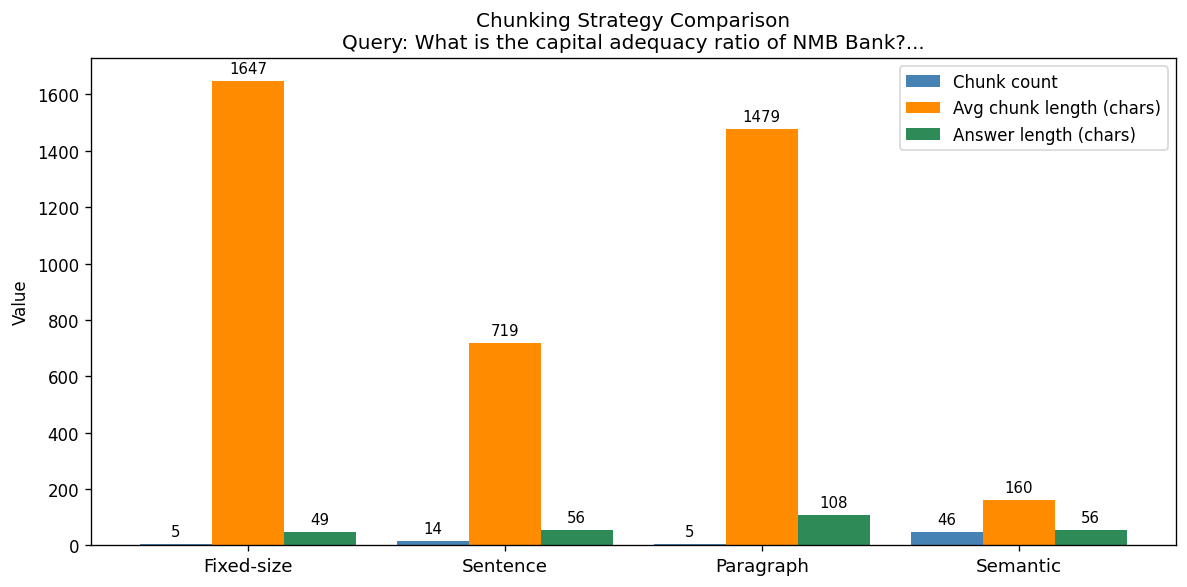

In [10]:
# Visualize: chunk count vs avg length vs answer length per strategy
all_chunks = {
    "Fixed-size" : chunks_fixed,
    "Sentence"   : chunks_sentence,
    "Paragraph"  : chunks_para,
    "Semantic"   : chunks_semantic,
}

names      = list(all_chunks.keys())
counts     = [len(v) for v in all_chunks.values()]
avg_lens   = [int(np.mean([len(c) for c in v])) for v in all_chunks.values()]
ans_lens   = [len(answers[n]) for n in names]

x = np.arange(len(names))
width = 0.28

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, counts,   width, label="Chunk count",          color="steelblue")
bars2 = ax.bar(x,         avg_lens, width, label="Avg chunk length (chars)", color="darkorange")
bars3 = ax.bar(x + width, ans_lens, width, label="Answer length (chars)",    color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Value")
ax.set_title(f"Chunking Strategy Comparison\nQuery: {QUERY[:60]}...")
ax.legend()
ax.bar_label(bars1, padding=3, fontsize=9)
ax.bar_label(bars2, padding=3, fontsize=9)
ax.bar_label(bars3, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## When to Use Which Strategy for Financial Documents

| Question Type | Best Strategy | Reason |
|---------------|---------------|---------|
| Precise number lookup (*"What is the CAR?"*) | **Paragraph** or **Semantic** | Numbers appear in well-formed paragraphs or tables |
| Section summaries (*"Summarize MD&A"*) | **Paragraph** | Keeps narrative sections intact |
| Definition queries (*"What is Tier 1 capital?"*) | **Sentence** | Definitions often appear as standalone sentences |
| Long-form analysis | **Semantic** | Topic boundaries are respected |

**Rule of thumb for CA professionals:**  
> Use **paragraph-based** chunking as your default for narrative sections.  
> Use **fixed-size** when you need speed and predictability.  
> Use **semantic** when answer quality is critical and you can afford the extra embedding cost upfront.

In [11]:
# Second query: Summarize the auditor's observations
# Paragraph-based chunking tends to win here because audit opinions are full paragraphs

QUERY2 = "Summarize the auditor's observations"

print(f"Query: {QUERY2}\n")
for name, col in strategies.items():
    chunks_ret = query_collection(col, QUERY2)
    answer = generate_answer(chunks_ret, QUERY2)
    print(f"── {name} Strategy ──")
    print(textwrap.fill(answer, width=80))
    print()

Query: Summarize the auditor's observations



── Fixed-size Strategy ──
The auditor's report indicates that the financial statements of NMB Bank Limited
for the year ended July 15, 2023, present a true and fair view of the bank's
financial position and performance, in accordance with Nepal Financial Reporting
Standards and relevant regulations. Key audit matters included the expected
credit loss on loans and advances, which involved significant management
judgment, and the effectiveness of IT systems and controls, particularly
concerning the new core banking system.



── Sentence Strategy ──
The auditor's report indicates that NMB Bank Limited's financial statements for
the year ended Ashadh 31, 2080 present a true and fair view of its financial
position and performance, compliant with Nepal Financial Reporting Standards and
relevant banking regulations. Key audit matters highlighted include the
significant management judgment involved in determining expected credit loss
provisions on loans and advances, and the importance of IT systems and controls,
particularly following the deployment of a new core banking system.



── Paragraph Strategy ──
The auditor's report indicates that the financial statements of NMB Bank Limited
for the year ended July 15, 2023, present a true and fair view in accordance
with Nepal Financial Reporting Standards and relevant regulations. Key audit
matters include the significant management judgment involved in determining
expected credit loss provisions on loans and advances, and the reliance on IT
systems and controls, which were tested for effectiveness.



── Semantic Strategy ──
The provided context does not include specific observations or findings from the
auditor regarding NMB Bank Limited's financial statements. Therefore, I cannot
summarize the auditor's observations.

